# Exercises 1 - Binary Classification with Keras

- Id: 22302421
- Full name: Nguyễn Phúc Minh Châu

This notebook is a **practice exercise** for students on **binary classification using Keras**.

Dataset: Breast Cancer Wisconsin

The goal is to build, train, and evaluate a neural network model.


## Requirements

Requirement 1: Load the Breast Cancer dataset from scikit-learn.

Requirement 2: Split the dataset into training and test sets.

Requirement 3: Normalize the input features.

Requirement 4: Build a neural network for binary classification using Keras.

Requirement 5: Train the model and use validation data.

Requirement 6: Plot training and validation loss and accuracy.

Requirement 7: Evaluate the model using Confusion Matrix and Classification Report.


In [1]:
# Import các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

I0000 00:00:1778209917.435385   59777 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778209917.503212   59777 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778209918.988742   59777 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Step 1: Load Dataset

Load the Breast Cancer dataset and extract input features X and labels y.


In [2]:
# TODO: Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (569, 30)
Output shape: (569,)


## Step 2: Train-Test Split and Normalization

Split the dataset into training and test sets.
Apply feature scaling using StandardScaler.


In [3]:
# TODO: Split data and normalize features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 3: Build Neural Network Model

Build a neural network for binary classification.
Use Sigmoid activation in the output layer.


In [4]:
# Khởi tạo mô hình
model = Sequential()

# TODO: Add hidden layers
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
# TODO: Add output layer with sigmoid activation
model.add(Dense(1, activation='sigmoid'))
# TODO: Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/home/zhu/micromamba/envs/tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1778210107.790792   59777 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Step 4: Train the Model

Train the model using training data.
Use validation_split to monitor overfitting.


In [5]:
# TODO: Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5467 - loss: 0.8509 - val_accuracy: 0.6374 - val_loss: 0.7832
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6786 - loss: 0.6653 - val_accuracy: 0.7143 - val_loss: 0.6109
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7665 - loss: 0.5283 - val_accuracy: 0.7912 - val_loss: 0.4967
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8187 - loss: 0.4356 - val_accuracy: 0.8462 - val_loss: 0.4166
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8462 - loss: 0.3689 - val_accuracy: 0.8571 - val_loss: 0.3608
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8764 - loss: 0.3190 - val_accuracy: 0.8681 - val_loss: 0.3205
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8956 - loss: 0.2829 - val_accuracy: 0.9231 - val_loss: 0.2891
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9121 - loss: 0.2542 - val_accuracy: 0.9231 - va

## Step 5: Visualization

Plot training and validation loss.
Plot training and validation accuracy.


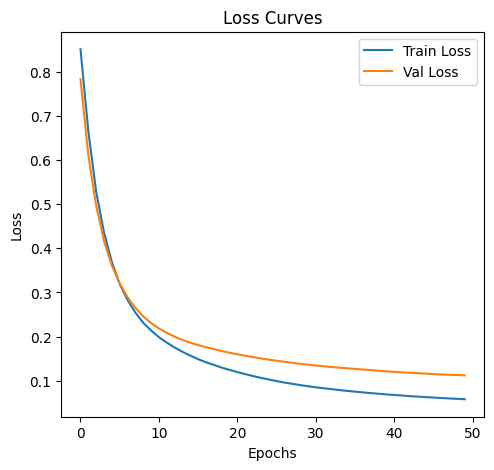

In [6]:
# TODO: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

## Step 6: Model Evaluation

Evaluate the model on the test set.
Compute Confusion Matrix and Classification Report.


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


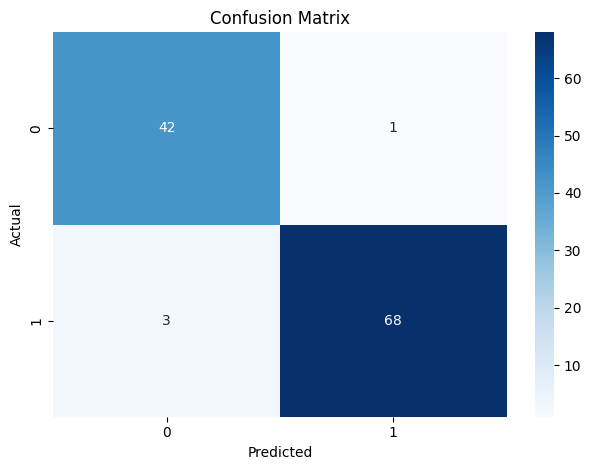

              precision    recall  f1-score   support

           0       0.93      0.98      0.95        43
           1       0.99      0.96      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [8]:
# TODO: Predict on test data
y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()
# TODO: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# TODO: Plot Confusion Matrix as heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
# TODO: Print classification report
print(classification_report(y_test, y_pred))

## Questions for Students

**Question 1: Why is Sigmoid used in the output layer for binary classification?**

Sigmoid is used in the output layer for binary classification because it maps the output to a value between 0 and 1, which can be interpreted as a probability of belonging to the positive class. This allows us to easily threshold the output (e.g., at 0.5) to make a binary decision.

**Question 2: What happens if the learning rate is too large?**
    
If the learning rate is too large, the model may overshoot the optimal solution during training, leading to unstable convergence or even divergence. The loss function might not decrease consistently, and the model may fail to learn the underlying patterns in the data.

**Question 3: How does batch size affect training stability?**
    
The batch size affects training stability in several ways. A smaller batch size can lead to noisier gradient estimates, which might cause the training process to be less stable but can also help escape local minima. Conversely, a larger batch size provides a more accurate estimate of the gradient, leading to more stable updates but potentially slower convergence.
